# Creating More Features

In create_features.py, we took the existing features and manipulated them to create more features for analysis. Now, there are 74 features that could be taken into consideration by the models during learning.

The data was also compressed into 1 row per athlete.

In [8]:
import pandas as pd

df = pd.read_parquet(
    "../data/processed/athletes_features.parquet"
)

print(df.shape)

print(df.columns)

display(df)

# print(df.iloc[1])

(10747, 74)
Index(['ACA', 'FIS ID', 'Name', 'YOB', 'Gender', 'total_race_starts',
       'total_finishes', 'overall_finish_rate', 'wins', 'podiums', 'top_5s',
       'top_10s', 'peak_gs_wr', 'peak_sl_wr', 'peak_sg_wr', 'peak_dh_wr',
       'GS starts', 'SG starts', 'SL starts', 'GS wins', 'GS podiums',
       'GS top 5s', 'GS top 10s', 'SL wins', 'SL podiums', 'SL top 5s',
       'SL top 10s', 'SG wins', 'SG podiums', 'SG top 5s', 'SG top 10s',
       'GS finish rate', 'SG finish rate', 'SL finish rate',
       'Zone avg percentile', 'Zone percentile sample size',
       'Provincial avg percentile', 'Provincial percentile sample size',
       'Regional avg percentile', 'Regional percentile sample size',
       'National avg percentile', 'National percentile sample size',
       'International avg percentile', 'International percentile sample size',
       'GS Zone avg percentile', 'GS Zone percentile sample size',
       'GS Provincial avg percentile', 'GS Provincial percentile sample 

,ACA,FIS ID,Name,YOB,Gender,total_race_starts,total_finishes,overall_finish_rate,wins,podiums,...,SG Zone avg percentile,SG Zone percentile sample size,SG Provincial avg percentile,SG Provincial percentile sample size,SG Regional avg percentile,SG Regional percentile sample size,SG National avg percentile,SG National percentile sample size,SG International avg percentile,SG International percentile sample size
0,4056,<NA>,"Swan, Bobby",1943.0,M,39,32,0.820513,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,21837,108259,"Ferguson, Jessie",2002.0,F,73,67,0.917808,2,3,...,NaN,NaN,0.739192,7.0,NaN,NaN,0.608856,2.0,0.333333,1.0
2,24413,<NA>,"Harrison, Wendy",1961.0,F,1,0,0.000000,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,24463,<NA>,"Whittaker, Gerry",1955.0,M,13,12,0.923077,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,24508,<NA>,"Grant, John William",1965.0,M,10,9,0.900000,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10742,122484,<NA>,"Hunter, Kade",2011.0,M,4,4,1.000000,0,0,...,NaN,NaN,0.794118,1.0,NaN,NaN,NaN,NaN,NaN,NaN
10743,122495,40831,"Woon, Henry",2010.0,M,3,1,0.333333,0,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10744,123396,<NA>,"Van Vliet, Sienna",2019.0,F,5,4,0.800000,0,0,...,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN
10745,123397,<NA>,"Findlay, Sophia",2018.0,F,5,5,1.000000,0,0,...,NaN,NaN,0.122807,1.0,NaN,NaN,NaN,NaN,NaN,NaN


## Visualizing the Features

Gender
M    5511
F    5235
Name: count, dtype: Int64


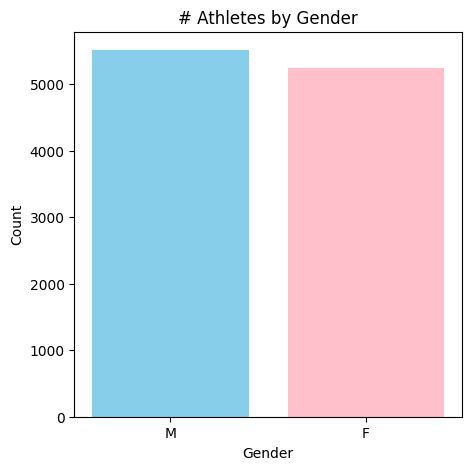

YOB
2001.0    874
2007.0    834
2009.0    788
2004.0    779
2003.0    778
2002.0    758
2008.0    751
2000.0    734
2005.0    733
1999.0    710
2006.0    704
1998.0    578
2010.0    536
1997.0    468
2011.0    452
1996.0     65
1995.0     33
2014.0     27
2012.0     24
2013.0     22
2015.0     18
2016.0     17
2017.0     11
1994.0      9
2018.0      8
1988.0      5
1993.0      3
1991.0      3
1970.0      2
2019.0      2
1992.0      2
1961.0      2
1955.0      2
1965.0      2
1979.0      1
1960.0      1
1967.0      1
1986.0      1
1944.0      1
1972.0      1
1953.0      1
1975.0      1
1959.0      1
1957.0      1
1958.0      1
1963.0      1
1943.0      1
Name: count, dtype: int64


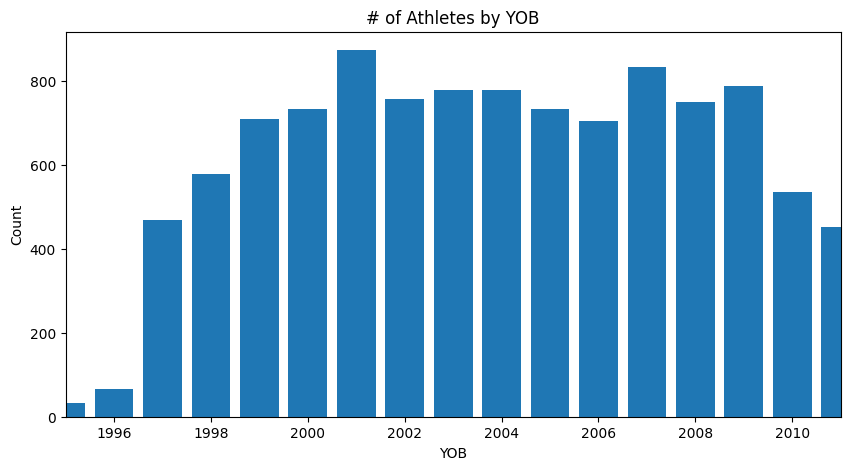

[np.int64(3158), np.int64(7589)]


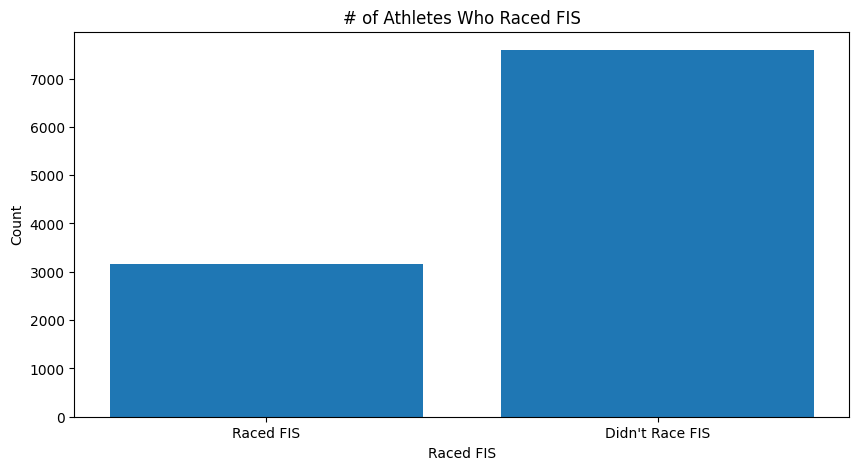

In [9]:
import matplotlib.pyplot as plt

# number of athletes by gender
gender_counts = df['Gender'].value_counts()
print(gender_counts)
plt.figure(figsize=(5, 5))
plt.bar(gender_counts.index, gender_counts.values, color=['skyblue', 'pink'])
plt.title('# Athletes by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.show()

# number of athletes by YOB
yob_counts = df['YOB'].value_counts()
print(yob_counts)
plt.figure(figsize=(10, 5))
plt.bar(yob_counts.index, yob_counts.values)
plt.title('# of Athletes by YOB')
plt.xlabel('YOB')
plt.ylabel('Count')
plt.xlim(1995, 2011)
plt.show()

# number of athletes who raced FIS vs didn't 
fis_counts = [
    df["FIS ID"].notna().sum(),
    df["FIS ID"].isna().sum()
]
labels = ["Raced FIS", "Didn't Race FIS"]
print(fis_counts)
plt.figure(figsize=(10, 5))
plt.bar(labels, fis_counts)
plt.title('# of Athletes Who Raced FIS')
plt.xlabel('Raced FIS')
plt.ylabel('Count')
plt.show()